In [ ]:
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt

In [16]:
xr.open_dataarray('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/daily/olr.day.nc')

<xarray.DataArray 'olr' (time: 17212, lat: 91, lon: 180)>
[281932560 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1978-01-01 1978-01-02 ... 2025-02-14
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float32 90.0 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0 -90.0

In [26]:
# Load dataset
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/olr.day.mean.nc'
ds = xr.open_dataset(fn)
olr = ds['olr'].sel(time=slice('1979-01-01', None))

# interpolate to 2x2 grid using xarray
olr_interp = olr.interp(lat=np.arange(90, -91, -2), lon=np.arange(0, 360, 2))
olr_interp = olr_interp.rename({'lat': 'lat_2', 'lon': 'lon_2'})
olr_interp = olr_interp.assign_coords(lat_2=olr_interp.lat_2, lon_2=olr_interp.lon_2)
olr_interp = olr_interp.rename('olr')
# olr_interp.to_netcdf('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/olr.day.mean.2x2.nc')

In [27]:
olr_interp = olr_interp.rename({'lat_2': 'lat', 'lon_2': 'lon'})
olr_interp = olr_interp.assign_coords(lat=olr_interp.lat, lon=olr_interp.lon)
olr_interp = olr_interp.rename('olr')

olr_interp[:,:,-1] = 0.5 * (olr_interp[:,:,0].values + olr_interp[:,:,-2].values)
olr_interp 

<xarray.DataArray 'olr' (time: 16071, lat: 91, lon: 180)>
array([[[156.75000006, 156.75000006, 156.7500001 , ..., 156.74999994,
         156.74999994, 156.75      ],
        [153.99000245, 153.99000245, 154.0139966 , ..., 153.94999999,
         153.94999999, 153.97000122],
        [160.28999949, 166.84199648, 171.24599609, ..., 172.40199699,
         170.92839737, 165.60919843],
        ...,
        [183.86999512, 183.58199708, 183.29159669, ..., 184.68439755,
         184.42599547, 184.14799529],
        [181.77999568, 181.58799376, 181.41999326, ..., 182.27599659,
         182.09999561, 181.93999565],
        [178.09999084, 178.09999084, 178.09999084, ..., 178.09999084,
         178.09999084, 178.09999084]],

       [[155.99999997, 155.99999997, 156.        , ..., 155.99999998,
         155.99999999, 155.99999998],
        [155.05599365, 155.05599365, 155.07999512, ..., 154.99359863,
         155.00640137, 155.03119751],
        [155.31799316, 159.20599613, 163.87279615, ..., 163.21399889,
         161.19719839, 158.25759578],
...
        [170.5       , 170.5       , 170.5       , ..., 170.10000001,
         170.10000001, 170.3       ],
        [170.19999981, 170.19999981, 170.19999981, ..., 168.79999995,
         168.79999995, 169.49999988],
        [166.        , 166.        , 166.        , ..., 166.        ,
         166.        , 166.        ]],

       [[177.49999994, 177.49999994, 177.49999994, ..., 177.50000012,
         177.50000012, 177.50000003],
        [180.69999999, 180.69999999, 180.69999999, ..., 180.10000002,
         180.10000002, 180.40000001],
        [190.5       , 190.5       , 190.5       , ..., 187.19999981,
         187.19999981, 188.8499999 ],
        ...,
        [170.5       , 170.5       , 170.5       , ..., 170.10000001,
         170.10000001, 170.3       ],
        [170.19999981, 170.19999981, 170.19999981, ..., 168.79999995,
         168.79999995, 169.49999988],
        [166.        , 166.        , 166.        , ..., 166.        ,
         166.        , 166.        ]]])
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2022-12-31
  * lat      (lat) int64 90 88 86 84 82 80 78 76 ... -78 -80 -82 -84 -86 -88 -90
  * lon      (lon) int64 0 2 4 6 8 10 12 14 ... 344 346 348 350 352 354 356 358
Attributes:
    units:         W/m^2
    var_desc:      Outgoing Longwave Radiation
    precision:     2
    dataset:       NOAA Interpolated OLR
    level_desc:    Other
    statistic:     Mean
    parent_stat:   Individual Obs
    valid_range:   [  0. 500.]
    long_name:     Daily Mean OLR
    actual_range:  [ 64.75 344.5 ]

<xarray.DataArray 'olr' (time: 16071, lat: 89, lon: 180)>
array([[[153.99000245, 153.99000245, 154.0139966 , ..., 153.94999999,
         153.94999999, 153.97000122],
        [160.28999949, 166.84199648, 171.24599609, ..., 172.40199699,
         170.92839737, 165.60919843],
        [166.34999698, 177.28599299, 184.63399535, ..., 186.37799437,
         184.01639404, 175.18319551],
        ...,
        [186.18999636, 185.58199828, 185.01959717, ..., 187.31479676,
         187.14439514, 186.66719575],
        [183.86999512, 183.58199708, 183.29159669, ..., 184.68439755,
         184.42599547, 184.14799529],
        [181.77999568, 181.58799376, 181.41999326, ..., 182.27599659,
         182.09999561, 181.93999565]],

       [[155.05599365, 155.05599365, 155.07999512, ..., 154.99359863,
         155.00640137, 155.03119751],
        [155.31799316, 159.20599613, 163.87279615, ..., 163.21399889,
         161.19719839, 158.25759578],
        [157.23799431, 163.70199831, 171.45599674, ..., 170.3059973 ,
         167.05399408, 162.1459942 ],
...
        [172.29999995, 172.29999995, 172.29999995, ..., 171.19999999,
         171.19999999, 171.74999997],
        [170.5       , 170.5       , 170.5       , ..., 170.10000001,
         170.10000001, 170.3       ],
        [170.19999981, 170.19999981, 170.19999981, ..., 168.79999995,
         168.79999995, 169.49999988]],

       [[180.69999999, 180.69999999, 180.69999999, ..., 180.10000002,
         180.10000002, 180.40000001],
        [190.5       , 190.5       , 190.5       , ..., 187.19999981,
         187.19999981, 188.8499999 ],
        [189.20000029, 189.20000029, 189.20000029, ..., 186.45600109,
         186.20000029, 187.70000029],
        ...,
        [172.29999995, 172.29999995, 172.29999995, ..., 171.19999999,
         171.19999999, 171.74999997],
        [170.5       , 170.5       , 170.5       , ..., 170.10000001,
         170.10000001, 170.3       ],
        [170.19999981, 170.19999981, 170.19999981, ..., 168.79999995,
         168.79999995, 169.49999988]]])
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2022-12-31
  * lat      (lat) int64 88 86 84 82 80 78 76 74 ... -76 -78 -80 -82 -84 -86 -88
  * lon      (lon) int64 0 2 4 6 8 10 12 14 ... 344 346 348 350 352 354 356 358
Attributes:
    units:         W/m^2
    var_desc:      Outgoing Longwave Radiation
    precision:     2
    dataset:       NOAA Interpolated OLR
    level_desc:    Other
    statistic:     Mean
    parent_stat:   Individual Obs
    valid_range:   [  0. 500.]
    long_name:     Daily Mean OLR
    actual_range:  [ 64.75 344.5 ]

In [28]:
olr_interp.sel(time='1979-01-01', lon=358)

<xarray.DataArray 'olr' (lat: 91)>
array([156.75      , 153.97000122, 165.60919843, 175.18319551,
       178.58399477, 184.07999577, 188.59839417, 189.07099487,
       190.69379462, 194.79039276, 198.81199164, 206.08239589,
       207.11999696, 204.90279559, 200.98419209, 195.49298874,
       182.35459262, 188.43179631, 200.89579531, 212.21999216,
       220.17999586, 214.34398745, 209.4469906 , 198.75099416,
       193.16459389, 221.2429997 , 227.75259652, 234.64199561,
       245.54319715, 259.24439735, 269.68998694, 274.2123968 ,
       277.02899415, 267.67339176, 250.51999292, 244.78399216,
       248.07118808, 250.4643919 , 248.55639366, 246.41359191,
       255.5759938 , 264.39918802, 262.40498842, 250.40978796,
       237.02558866, 238.65999897, 240.7959976 , 252.72519722,
       260.58119751, 260.63999692, 259.31999215, 261.26799501,
       264.78020028, 266.84499878, 266.86659188, 266.66499026,
       268.62899415, 271.46179138, 273.77419374, 274.70259826,
       273.90898743, 273.63378723, 271.65818907, 266.52619091,
       257.79899137, 246.05499109, 242.75738982, 233.3853901 ,
       226.2913922 , 222.48699331, 215.64298694, 209.51659544,
       205.70499753, 202.70979746, 201.91979527, 207.61098764,
       212.3557925 , 210.44959219, 207.41679375, 208.87659597,
       220.5429915 , 198.38459439, 183.63799627, 178.95399719,
       181.58539764, 183.386998  , 188.03579804, 186.66719575,
       184.14799529, 181.93999565, 178.09999084])
Coordinates:
    time     datetime64[ns] 1979-01-01
  * lat      (lat) int64 90 88 86 84 82 80 78 76 ... -78 -80 -82 -84 -86 -88 -90
    lon      int64 358
Attributes:
    units:         W/m^2
    var_desc:      Outgoing Longwave Radiation
    precision:     2
    dataset:       NOAA Interpolated OLR
    level_desc:    Other
    statistic:     Mean
    parent_stat:   Individual Obs
    valid_range:   [  0. 500.]
    long_name:     Daily Mean OLR
    actual_range:  [ 64.75 344.5 ]

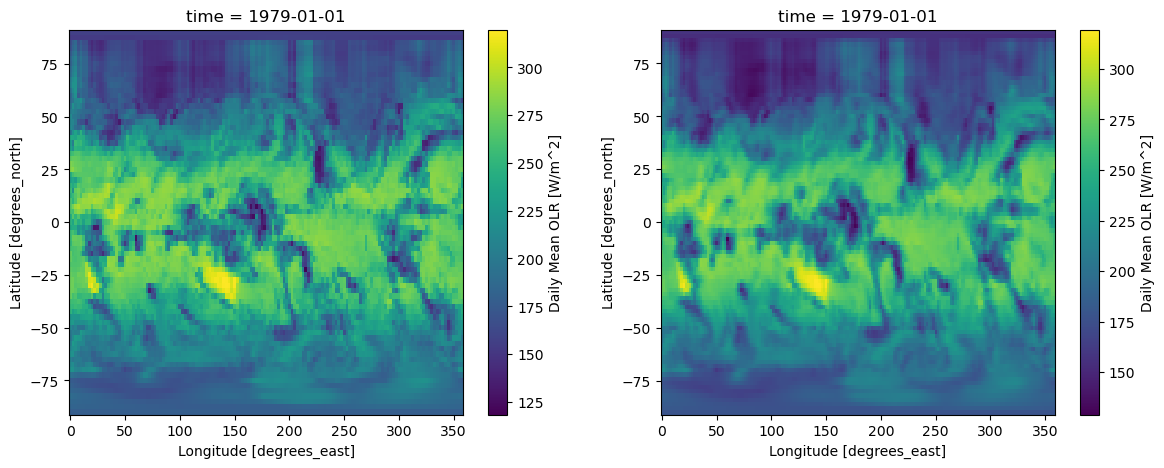

In [29]:
# check interpolation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
olr.isel(time=0).plot(ax=ax[0])
olr_interp.isel(time=0).plot(ax=ax[1])
plt.show()

In [30]:
# any missing values?
print('Number of missing values in original data:', olr.isnull().sum().values)
print('Number of missing values in interpolated data:', olr_interp.isnull().sum().values)

Number of missing values in original data: 0
Number of missing values in interpolated data: 0


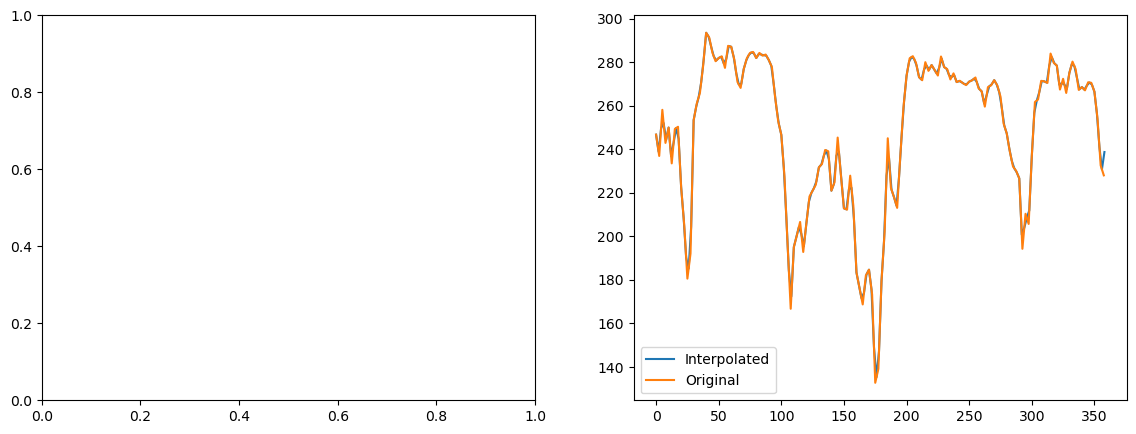

In [33]:
# check interpolation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.plot(olr_interp.lon, olr_interp.isel(time=0).sel(lat=0), label='Interpolated')
plt.plot(olr.lon, olr.isel(time=0).sel(lat=0), label='Original')
plt.legend()

In [35]:
# save interpolated data
olr_interp.to_netcdf('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/daily/olr.day.noaa.2x2.nc')

In [37]:
ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/daily/olr.day.noaa.2x2.nc')
# any missing values?
print('Number of missing values in interpolated data:', ds['olr'].isnull().sum().values)

Number of missing values in interpolated data: 0


In [40]:
# daily to anomaly 
from util.MJO_indices_util import get_anomalies_1var

# ========= parameters to be set ================
# we will get data anomalies for periods of date_sta to date_end
date_sta = '1979-01-01'
date_end = '2022-12-31'
year_sta = '1979'
year_end = '2022'

# this indicates which years are used to get the annual cycle.
yearclim_sta=1979
yearclim_end=2001

# daily data is stored in this directory.
data_path = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/daily/olr.day.noaa.2x2.nc'
data_store = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/anomaly/'

target_ano = get_anomalies_1var('olr', data_path, date_sta, date_end, latsel=90, yearclim_sta=yearclim_sta, yearclim_end=yearclim_end)

# Assign a name to the DataArray
data_array = target_ano.rename('olr')

# Convert the DataArray to a Dataset
dataset = data_array.to_dataset()

# Save the Dataset to an NC file
dataset.to_netcdf(data_store +'olr.anomaly.noaa.2x2.' + year_sta + 'to' + year_end + 'based' + str(yearclim_sta) + 'to' + str(yearclim_end) + '.nc', mode='w')

# Close the Dataset
dataset.close()





start compute: olr
shape of raw climatological maps:  (366, 91, 180)


In [42]:
# check anomaly 
ds = xr.open_dataarray('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/anomaly/olr.anomaly.noaa.2x2.1979to2022based1979to2001.nc')
ds.isnull().sum().values

array(0)

In [43]:
# anomaly to filtered anomaly
from util.MJO_indices_util import rmv_runavg

date_sta = '1979-01-01'
date_end = '2022-12-31'
year_sta = '1979'
year_end = '2022'

# this indicates which years are used to get the annual cycle.
yearclim_sta=1979
yearclim_end=2001

data_path = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/anomaly/olr.anomaly.noaa.2x2.1979to2022based1979to2001.nc'
data_store = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/fltano120/'
# ================================================

ds = xr.open_dataset(data_path)
target_ano = ds['olr']

flt_ano = rmv_runavg(target_ano, window_size=120)  # remove the previous 120-day running averages

flt_ano_sel = flt_ano.sel(time=slice(date_sta, date_end))

# Assign a name to the DataArray
data_array = flt_ano_sel.rename('olr')

# Convert the DataArray to a Dataset
dataset = data_array.to_dataset()

# Save the Dataset to an NC file
dataset.to_netcdf(data_store + 'olr.fltano120.noaa.2x2.' + year_sta + 'to' + year_end + 'based' + str(yearclim_sta) + 'to' + str(yearclim_end) + '.nc', mode='w')

# Close the Dataset
dataset.close()
ds.close()

In [44]:
# check filtered anomaly
ds = xr.open_dataarray('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/fltano120/olr.fltano120.noaa.2x2.1979to2022based1979to2001.nc')
ds.isnull().sum().values


array(0)

In [45]:
ds 

<xarray.DataArray 'olr' (time: 15952, lat: 91, lon: 180)>
array([[[ 4.841626,  4.841626, ...,  4.841626,  4.841626],
        [ 1.442617,  1.38222 , ...,  2.11936 ,  1.780988],
        ...,
        [14.304693, 14.48984 , ..., 13.85998 , 14.082337],
        [16.011973, 16.011973, ..., 16.011973, 16.011973]],

       [[ 8.09436 ,  8.094361, ...,  8.094361,  8.094361],
        [ 4.45544 ,  4.459216, ...,  4.995424,  4.725432],
        ...,
        [11.87605 , 12.153475, ..., 11.273691, 11.574871],
        [-0.412163, -0.412163, ..., -0.412163, -0.412163]],

       ...,

       [[13.036091, 13.03609 , ..., 13.036091, 13.036091],
        [15.627843, 15.623537, ..., 15.465273, 15.546558],
        ...,
        [-2.60172 , -2.672189, ..., -5.097436, -3.849578],
        [-1.975865, -1.975865, ..., -1.975865, -1.975865]],

       [[12.961303, 12.961303, ..., 12.961303, 12.961303],
        [15.543661, 15.539068, ..., 15.378844, 15.461252],
        ...,
        [-2.488752, -2.558367, ..., -4.937513, -3.713132],
        [-1.849345, -1.849345, ..., -1.849345, -1.849345]]])
Coordinates:
  * time       (time) datetime64[ns] 1979-04-30 1979-05-01 ... 2022-12-31
  * lat        (lat) int64 90 88 86 84 82 80 78 ... -78 -80 -82 -84 -86 -88 -90
  * lon        (lon) int64 0 2 4 6 8 10 12 14 ... 346 348 350 352 354 356 358
    dayofyear  (time) int64 ...

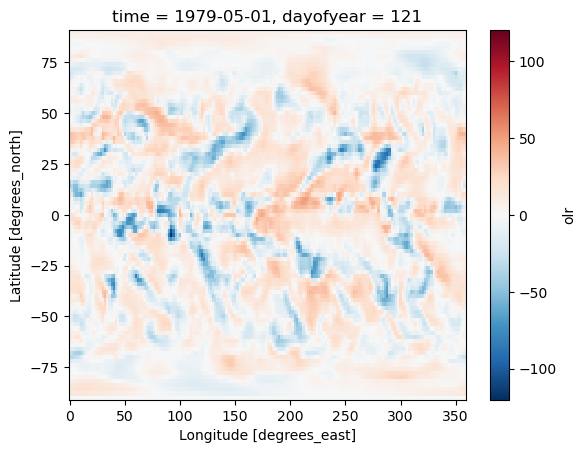

In [47]:
ds.sel(time='1979-05-01').plot()

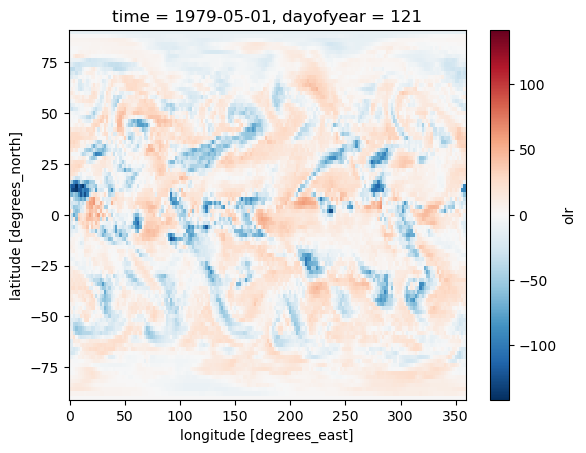

In [48]:
xr.open_dataarray('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/fltano120/olr.fltano120.1978to2025based1979to2001.nc').sel(time='1979-05-01').plot()